# Hệ Thống Hybrid Quantum-Classical QML 🚀

**Mục tiêu:** Sử dụng QCNN (Pennylane + PyTorch) làm Feature Extractor để trích xuất không gian lượng tử đa chiều, sau đó kết hợp với các đặc trưng cổ điển để huấn luyện XGBoost và CatBoost.

**Đặc trưng Lượng tử:**
- Chỉ sử dụng 8 Features Mới (sinh ra từ Feature Engineering) nạp vào hệ thống lượng tử.
- Đầu ra lượng tử có thể là 8 Expectation Values hoặc 256 Statevector Probabilities.


In [1]:
!pip install -q pennylane torch xgboost catboost seaborn matplotlib-venn openpyxl upsetplot
import pandas as pd
import numpy as np
import time
import os
import gc
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2, venn3
from upsetplot import plot as upset_plot, from_memberships
import xgboost as xgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# CẤU HÌNH HỆ THỐNG HYBRID QML SOTA
# ==========================================
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- 1. CẤU HÌNH FEATURE LƯỢNG TỬ ---
QUANTUM_FEATURE_TYPE = 'EXPECTATION'
# 'EXPECTATION': Đo lường giá trị kỳ vọng Z tại từng Qubit (8 features).
# 'STATEVECTOR': Trích xuất toàn bộ véc-tơ phân phối xác suất (256 features).

# --- 2. CẤU HÌNH KIẾN TRÚC QCNN (FIXED) ---
CONV_DEPTHS = [6, 6, 5]  

# --- 3. CẤU HÌNH CLASSICAL HEADS (SOTA PARAMS) ---
# Dựa trên best params từ attacker-2026 - classic.ipynb
# 🌲 XGBoost SOTA
XGB_N_ESTIMATORS = 1000        # Số lượng cây tối đa (Dùng kết hợp Early Stopping)
XGB_LEARNING_RATE = 0.03       # Tốc độ học (Nhỏ giúp mô hình hội tụ từ từ, chắc chắn)
XGB_MAX_DEPTH = 5              # Độ sâu tối đa (5 để tránh overfit quá mức)
XGB_SUBSAMPLE = 0.8            # Tỷ lệ lấy mẫu dữ liệu ngẫu nhiên cho mỗi cây (80%)
XGB_COLSAMPLE_BYTREE = 0.8     # Tỷ lệ lấy mẫu feature ngẫu nhiên cho mỗi cây (80%)
XGB_REG_ALPHA = 0.5            # Phạt L1 (Lasso) để loại bỏ feature lượng tử rác
XGB_REG_LAMBDA = 2.0           # Phạt L2 (Ridge) để chống bùng nổ trọng số
XGB_EARLY_STOPPING = 50        # Dừng sớm nếu sau 50 cây không giảm loss trên tập Val

# 🐱 CatBoost SOTA
CB_ITERATIONS = 1000
CB_LEARNING_RATE = 0.03
CB_DEPTH = 6
CB_L2_LEAF_REG = 5.0           # Phạt L2 cực mạnh đặc trưng của CatBoost
CB_EARLY_STOPPING = 50

os.makedirs('hybrid_results', exist_ok=True)
print("✅ Khởi tạo Cấu hình Hybrid SOTA thành công!")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Khởi tạo Cấu hình Hybrid SOTA thành công!


## 1. Cấu hình Hệ thống (Config)


In [2]:
import pandas as pd
import numpy as np
import time
import os
import gc
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, precision_recall_curve

import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2, venn3
import xgboost as xgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# CẤU HÌNH HỆ THỐNG HYBRID QML
# ==========================================
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- 1. CẤU HÌNH FEATURE LƯỢNG TỬ ---
QUANTUM_FEATURE_TYPE = 'EXPECTATION'
# 'EXPECTATION': Đo lường giá trị kỳ vọng Z tại từng Qubit trước Pooling cuối (Tạo 8 features).
# 'STATEVECTOR': Trích xuất toàn bộ véc-tơ phân phối xác suất (Tạo 256 features).

# --- 2. CẤU HÌNH KIẾN TRÚC QCNN (FIXED) ---
CONV_DEPTHS = [6, 6, 5]  
# Mạch cố định, dùng làm hàm băm phi tuyến chiếu dữ liệu.

# --- 3. CẤU HÌNH HUẤN LUYỆN (DYNAMIC LR) ---
MAX_EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.01

AUTO_REDUCE_LR = True
LR_PATIENCE = 3
LR_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 5

os.makedirs('hybrid_results', exist_ok=True)
print("✅ Khởi tạo Cấu hình Hybrid thành công!")
print(f"   - Phương pháp trích xuất lượng tử: {QUANTUM_FEATURE_TYPE}")
print(f"   - Độ sâu mạch (Fixed): {CONV_DEPTHS}")
# --- 3. CẤU HÌNH CLASSICAL HEADS & FUSION ---
CLASSIC_FEATURE_MODE = 'QUANTUM_ONLY' 
# Chọn 1 trong 5: 'QUANTUM_ONLY', 'QUANTUM_ALL', 'QUANTUM_ONLY_NEW', 'QUANTUM_ONLY_ORIGINAL', 'QUANTUM_NEW_AND_UNUSED_ORIGINAL'

# Tham số XGBoost (Gợi ý: max_depth thấp để tránh overfit feature lượng tử)
XGB_LEARNING_RATE = 0.05
XGB_MAX_DEPTH = 6
XGB_SUBSAMPLE = 0.8
XGB_COLSAMPLE_BYTREE = 0.8

# Tham số CatBoost (Gợi ý: L2 mạnh để chặn bùng nổ trọng số lá)
CB_LEARNING_RATE = 0.05
CB_DEPTH = 6
CB_L2_LEAF_REG = 3


✅ Khởi tạo Cấu hình Hybrid thành công!
   - Phương pháp trích xuất lượng tử: EXPECTATION
   - Độ sâu mạch (Fixed): [6, 6, 5]


## 2. Tiền xử lý dữ liệu (Classic Feature Engineering)


In [3]:
# Đọc dữ liệu
df = pd.read_excel('/kaggle/input/attacker-2026-credit-risk/Credit Risk Dataset (1).xlsx')
X = df.drop(columns=['loan_status'])
y = df['loan_status']

numeric_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# --- Chia dữ liệu (Ratio) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print(f"Dữ liệu gốc Train: {X_train.shape} | Test: {X_test.shape}")

# --- Feature Engineering ---
def engineer_features(X_tr, X_te):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for s in [X_tr, X_te]:
        s['income_per_age']             = s['person_income'] / s['person_age']
        s['emp_stability_ratio']        = s['person_emp_length'] / (s['person_age'] - 18 + 1e-5)
        s['loan_to_emp_length']         = s['loan_amnt'] / (s['person_emp_length'] + 1)
        s['estimated_interest_burden']  = s['loan_amnt'] * (s['loan_int_rate'] / 100)
        s['is_anomaly_emp']             = (s['person_emp_length'] > (s['person_age'] - 14)).astype(int)
        s['is_extreme_loan']            = (s['loan_percent_income'] > 0.5).astype(int)
    h = X_tr.groupby('person_home_ownership')['person_income'].mean()
    g = X_tr.groupby('loan_grade')['loan_amnt'].mean()
    for s in [X_tr, X_te]:
        s['income_vs_home_mean'] = s['person_income'] / s['person_home_ownership'].map(h)
        s['loan_vs_grade_mean']  = s['loan_amnt']    / s['loan_grade'].map(g)
    X_te[['income_vs_home_mean','loan_vs_grade_mean']] = \
        X_te[['income_vs_home_mean','loan_vs_grade_mean']].fillna(1.0)
    return X_tr, X_te

X_train_eng, X_test_eng = engineer_features(X_train, X_test)

# 8 Features mới
new_num_cols = ['income_per_age','emp_stability_ratio','loan_to_emp_length',
                'estimated_interest_burden','is_anomaly_emp','is_extreme_loan',
                'income_vs_home_mean','loan_vs_grade_mean']

print(f"✅ Tạo thành công 8 Đặc trưng mới!")

Dữ liệu gốc Train: (26064, 28) | Test: (6517, 28)
✅ Tạo thành công 8 Đặc trưng mới!


## 3. Tiền xử lý Dữ liệu Lượng Tử (Tái tạo PCA 8D khớp với Model cũ)


In [4]:
# =====================================================================
# TÁI TẠO BỘ TIỀN XỬ LÝ PCA Y HỆT FILE GỐC ĐỂ DÙNG LẠI MODEL CŨ
# (Sử dụng cấu hình ONLY_NEW + PCA 8D)
# =====================================================================
from sklearn.decomposition import PCA

# 1. Trích xuất đúng 8 Features mới (ONLY_NEW)
X_train_q = X_train_eng[new_num_cols].copy()
X_test_q  = X_test_eng[new_num_cols].copy()

# 2. Chuẩn hóa (StandardScaler)
q_preprocessor = Pipeline([
    ('imp', SimpleImputer(strategy='median')), 
    ('sc', StandardScaler())
])

X_train_q_std = q_preprocessor.fit_transform(X_train_q).astype('float32')
X_test_q_std = q_preprocessor.transform(X_test_q).astype('float32')

# 3. Ép PCA 8D (Thực chất là phép xoay trục và giải tương quan)
pca = PCA(n_components=8, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_q_std).astype('float32')
X_test_pca = pca.transform(X_test_q_std).astype('float32')

ev = np.sum(pca.explained_variance_ratio_)
print(f"📊 PCA: 8D → 8D | Phép quay trục (Rotation) giữ lại {ev*100:.2f}% thông tin")

# 4. Map về miền [-π, π] cho Angle Embedding
A_train = (np.tanh(X_train_pca) * np.pi).astype('float32')
A_test  = (np.tanh(X_test_pca) * np.pi).astype('float32')

n_qubits = 8

print(f"✅ Đã chuẩn bị dữ liệu cho Lượng Tử: Map vào {n_qubits} Qubits bằng PCA (Từ ONLY_NEW)!")


📊 PCA: 8D → 8D | Phép quay trục (Rotation) giữ lại 100.00% thông tin
✅ Đã chuẩn bị dữ liệu cho Lượng Tử: Map vào 8 Qubits bằng PCA (Từ ONLY_NEW)!


## 4. Kiến trúc Mạch Lượng Tử (Pennylane + PyTorch)


In [5]:
# Hàm tính tổng tham số
def compute_qcnn_param_count(n_qubits, conv_depths):
    total, wires = 0, list(range(n_qubits))
    layer = 1
    while len(wires) > 1:
        n_pairs = len(wires) // 2
        depth = conv_depths[layer - 1] if layer - 1 < len(conv_depths) else 1
        conv_params = n_pairs * 3 * depth
        pool_params = n_pairs
        total += conv_params + pool_params
        
        kept = [wires[2*j+1] for j in range(n_pairs)]
        if len(wires) % 2 == 1:
            kept.append(wires[-1])
        wires = kept
        layer += 1
    return total, wires[0]

# Xây dựng mạch Pennylane
def build_qcnn(n_qubits, conv_depths):
    dev = qml.device('default.qubit', wires=n_qubits)

    wire_layers = []
    wires = list(range(n_qubits))
    while len(wires) > 1:
        wire_layers.append(list(wires))
        n_pairs = len(wires) // 2
        kept = [wires[2*j+1] for j in range(n_pairs)]
        if len(wires) % 2 == 1:
            kept.append(wires[-1])
        wires = kept
    final_wire = wires[0]
    
    def qcnn_ansatz(inputs, params):
        # 1. Angle Embedding
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        
        # 2. Conv & Pool
        p = 0
        layer = 1
        for layer_wires in wire_layers:
            n_pairs = len(layer_wires) // 2
            depth = conv_depths[layer - 1] if layer - 1 < len(conv_depths) else 1
            for d in range(depth):
                for j in range(n_pairs):
                    w1, w2 = layer_wires[2*j], layer_wires[2*j+1]
                    qml.RY(params[p],   wires=w1)
                    qml.RY(params[p+1], wires=w2)
                    qml.CNOT(wires=[w1, w2])
                    qml.RZ(params[p+2], wires=w1)
                    p += 3
            for j in range(n_pairs):
                w1, w2 = layer_wires[2*j], layer_wires[2*j+1]
                qml.CRZ(params[p], wires=[w1, w2])
                p += 1
            layer += 1

    # Mạch dùng để TRAIN (phân loại)
    @qml.qnode(dev, interface='torch', diff_method='best')
    def train_circuit(inputs, params):
        qcnn_ansatz(inputs, params)
        return qml.probs(wires=[final_wire])

    # Mạch dùng để FEATURE EXTRACTION (Trích xuất)
    @qml.qnode(dev, interface='torch', diff_method='best')
    def feature_circuit(inputs, params):
        qcnn_ansatz(inputs, params)
        if QUANTUM_FEATURE_TYPE == 'EXPECTATION':
            # 8 Features (Z-expectation tại tất cả qubit)
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        else:
            # 256 Features (Statevector probabilities)
            return qml.probs(wires=range(n_qubits))

    n_params, _ = compute_qcnn_param_count(n_qubits, conv_depths)
    return train_circuit, feature_circuit, n_params

class HybridQCNN(nn.Module):
    def __init__(self, n_qubits, conv_depths):
        super().__init__()
        self.train_circuit, self.feature_circuit, n_params = build_qcnn(n_qubits, conv_depths)
        self.circuit_params = nn.Parameter(0.05 * torch.randn(n_params))
        self.head = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        # Trả ra output 2 chiều để tối ưu CrossEntropyLoss
        q_out = self.train_circuit(x, self.circuit_params)
        return self.head(q_out.to(torch.float32))

    def extract_features(self, x):
        # Trả ra N-dimensional tensor cho mô hình Classical
        with torch.no_grad():
            features = self.feature_circuit(x, self.circuit_params)
            if QUANTUM_FEATURE_TYPE == 'EXPECTATION':
                # features là list của 8 tensors, ta stack lại
                features = torch.stack(features, dim=-1)
            return features.numpy()
            
print("✅ Định nghĩa Kiến trúc QCNN (Angle-NoPCA) hoàn tất!")

✅ Định nghĩa Kiến trúc QCNN (Angle-NoPCA) hoàn tất!


## 5. Nạp mô hình QCNN (Bỏ qua Huấn luyện)


In [6]:
print(f"\n{'='*60}\n🚀 NẠP TRỌNG SỐ QCNN TỪ FILE (Bỏ qua Huấn luyện)\n{'='*60}")

model = HybridQCNN(n_qubits, CONV_DEPTHS)

# Thay đường dẫn này bằng đường dẫn tới file model cũ của bạn trên Kaggle
MODEL_PATH = '/kaggle/input/attacker-2026-credit-risk/best_model.pth' 

if os.path.exists(MODEL_PATH):
    # Nạp trọng số
    checkpoint = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"✅ Đã nạp thành công trọng số QCNN từ {MODEL_PATH}!")
    
    # -------------------------------------------------------------
    # BƯỚC XÁC MINH (SANITY CHECK) TRÊN TẬP TEST
    # -------------------------------------------------------------
    print("\n🔍 Đang chạy kiểm tra (Sanity Check) model độc lập trên tập Test...")
    model.eval()
    with torch.no_grad():
        probs_test = []
        for i in range(0, len(A_test), 256):
            probs_test.append(torch.softmax(model.train_circuit(torch.tensor(A_test[i:i+256]), model.circuit_params), 1)[:, 1])
        test_probs = torch.cat(probs_test).numpy()
        
        # Vì model gốc được nối thêm một head PyTorch nhỏ (Linear -> ReLU -> Linear) để xuất ra 2 class
        # Ta gọi hàm forward đầy đủ của model để ra output xác suất thực sự.
        probs_test_full = []
        for i in range(0, len(A_test), 256):
            probs_test_full.append(torch.softmax(model(torch.tensor(A_test[i:i+256])), 1)[:, 1])
        test_probs_full = torch.cat(probs_test_full).numpy()
        
        val_auc = roc_auc_score(y_test, test_probs_full)
        print(f"🎯 Kết quả Đánh giá QCNN Standalone trên Test Set:")
        print(f"   ROC AUC = {val_auc:.4f}")
        print("   (Lưu ý: Nếu điểm số này khớp với AUC trong notebook cũ của bạn, quá trình nạp dữ liệu và trọng số đã thành công mỹ mãn!)")
        
else:
    print(f"⚠️ CẢNH BÁO: Không tìm thấy tệp {MODEL_PATH}.")
    print("Vui lòng tải tệp .pth lên Kaggle và sửa lại đường dẫn ở biến MODEL_PATH phía trên.")



🚀 NẠP TRỌNG SỐ QCNN TỪ FILE (Bỏ qua Huấn luyện)
✅ Đã nạp thành công trọng số QCNN từ /kaggle/input/attacker-2026-credit-risk/best_model.pth!

🔍 Đang chạy kiểm tra (Sanity Check) model độc lập trên tập Test...
🎯 Kết quả Đánh giá QCNN Standalone trên Test Set:
   ROC AUC = 0.8219
   (Lưu ý: Nếu điểm số này khớp với AUC trong notebook cũ của bạn, quá trình nạp dữ liệu và trọng số đã thành công mỹ mãn!)


## 6. Trích xuất Đặc trưng Lượng tử (Quantum Features)


In [7]:
print(f"👉 Bắt đầu trích xuất Quantum Features (Chế độ: {QUANTUM_FEATURE_TYPE})...")
model.eval()

# Trích xuất dạng batch để không tràn RAM với Statevector
def extract_in_batches(model, X_arr, batch_size=256):
    all_feats = []
    for i in range(0, len(X_arr), batch_size):
        batch = torch.tensor(X_arr[i:i+batch_size])
        feats = model.extract_features(batch)
        all_feats.append(feats)
    return np.vstack(all_feats)

Q_Train = extract_in_batches(model, A_train)
Q_Test  = extract_in_batches(model, A_test)

print(f"✅ Trích xuất thành công! Shape Train: {Q_Train.shape} | Shape Test: {Q_Test.shape}")

👉 Bắt đầu trích xuất Quantum Features (Chế độ: EXPECTATION)...
✅ Trích xuất thành công! Shape Train: (26064, 8) | Shape Test: (6517, 8)


## 7. Hợp nhất Dữ liệu (Data Fusion - Hybrid Dataset)


In [8]:
# Chuẩn bị Pipeline xử lý Data Cổ điển
original_num = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

preprocessor_all = ColumnTransformer(transformers=[
    ('num_orig', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), original_num),
    ('num_new', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), new_num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
                      ('sc', StandardScaler())]), cat_cols)
])

# Fit trên Train
preprocessor_all.fit(X_train_eng)

# Lấy ra từng mảng con
def get_blocks(X_df):
    arr = preprocessor_all.transform(X_df).astype('float32')
    # original: index 0 -> 6
    # new: index 7 -> 14
    # cat: index 15 -> 18
    return arr[:, :7], arr[:, 7:15], arr[:, 15:]

C_Tr_Orig, C_Tr_New, C_Tr_Cat = get_blocks(X_train_eng)
C_Te_Orig, C_Te_New, C_Te_Cat = get_blocks(X_test_eng)

# Tạo 5 bộ dữ liệu lai
hybrid_datasets = {}

# 1. QUANTUM ONLY
hybrid_datasets['QUANTUM_ONLY'] = (Q_Train, Q_Test)

# 2. QUANTUM + ALL
hybrid_datasets['QUANTUM_ALL'] = (
    np.hstack([Q_Train, C_Tr_Orig, C_Tr_New, C_Tr_Cat]),
    np.hstack([Q_Test, C_Te_Orig, C_Te_New, C_Te_Cat])
)

# 3. QUANTUM + ONLY_NEW
hybrid_datasets['QUANTUM_ONLY_NEW'] = (
    np.hstack([Q_Train, C_Tr_New]),
    np.hstack([Q_Test, C_Te_New])
)

# 4. QUANTUM + ONLY_ORIGINAL
hybrid_datasets['QUANTUM_ONLY_ORIGINAL'] = (
    np.hstack([Q_Train, C_Tr_Orig, C_Tr_Cat]),
    np.hstack([Q_Test, C_Te_Orig, C_Te_Cat])
)

# 5. QUANTUM + NEW_AND_UNUSED_ORIGINAL
# (Gồm: Quantum, New Features, Cat Features, và cb_person_cred_hist_length (index 6 của Orig))
hybrid_datasets['QUANTUM_NEW_AND_UNUSED_ORIGINAL'] = (
    np.hstack([Q_Train, C_Tr_New, C_Tr_Cat, C_Tr_Orig[:, 6:7]]),
    np.hstack([Q_Test, C_Te_New, C_Te_Cat, C_Te_Orig[:, 6:7]])
)

print(f"✅ Hợp nhất Data Fusion thành công cho 5 chiến thuật lai!")

✅ Hợp nhất Data Fusion thành công cho 5 chiến thuật lai!


## 8. Huấn luyện Mô hình Cổ điển (Classical Heads)


In [9]:
models_results = {}
all_test_probs = {}

pos_scale = np.sum(y_train == 0) / max(np.sum(y_train == 1), 1)

print(f"\n{'='*60}\n🚀 BẮT ĐẦU HUẤN LUYỆN CLASSICAL HEADS (VÒNG LẶP 5 CHIẾN THUẬT)\n{'='*60}")

for dataset_name, (X_tr_full, X_te) in hybrid_datasets.items():
    print(f"\n--- Đang xử lý chiến thuật: {dataset_name} ---")
    
    # Chia Validation phục vụ Early Stopping (Lấy 20% từ tập Train gốc)
    X_tr_inner, X_val, y_tr_inner, y_val = train_test_split(
        X_tr_full, y_train.values, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train.values
    )
    
    # 🌲 XGBoost SOTA
    xgb_model = xgb.XGBClassifier(
        n_estimators=XGB_N_ESTIMATORS, 
        learning_rate=XGB_LEARNING_RATE, 
        max_depth=XGB_MAX_DEPTH,
        subsample=XGB_SUBSAMPLE, 
        colsample_bytree=XGB_COLSAMPLE_BYTREE,
        reg_alpha=XGB_REG_ALPHA, 
        reg_lambda=XGB_REG_LAMBDA,
        early_stopping_rounds=XGB_EARLY_STOPPING, 
        scale_pos_weight=pos_scale,
        random_state=RANDOM_SEED, 
        eval_metric='auc', 
        n_jobs=-1
    )
    # Huấn luyện kèm Early Stopping
    xgb_model.fit(X_tr_inner, y_tr_inner, eval_set=[(X_val, y_val)], verbose=False)
    p_xgb = xgb_model.predict_proba(X_te)[:, 1]
    all_test_probs[f'XGB_{dataset_name}'] = p_xgb
    print(f"   ✅ XGBoost  | Best Iteration: {xgb_model.best_iteration} | Test AUC: {roc_auc_score(y_test, p_xgb):.4f}")

    # 🐱 CatBoost SOTA
    cb_model = CatBoostClassifier(
        iterations=CB_ITERATIONS, 
        learning_rate=CB_LEARNING_RATE, 
        depth=CB_DEPTH,
        l2_leaf_reg=CB_L2_LEAF_REG, 
        early_stopping_rounds=CB_EARLY_STOPPING,
        auto_class_weights='Balanced', 
        random_seed=RANDOM_SEED, 
        verbose=0
    )
    cb_model.fit(X_tr_inner, y_tr_inner, eval_set=[(X_val, y_val)], verbose=False)
    p_cb = cb_model.predict_proba(X_te)[:, 1]
    all_test_probs[f'CB_{dataset_name}'] = p_cb
    print(f"   ✅ CatBoost | Best Iteration: {cb_model.get_best_iteration()} | Test AUC: {roc_auc_score(y_test, p_cb):.4f}")



🚀 BẮT ĐẦU HUẤN LUYỆN CLASSICAL HEADS (VÒNG LẶP 5 CHIẾN THUẬT)

--- Đang xử lý chiến thuật: QUANTUM_ONLY ---
   ✅ XGBoost  | Best Iteration: 832 | Test AUC: 0.8432
   ✅ CatBoost | Best Iteration: 684 | Test AUC: 0.8392

--- Đang xử lý chiến thuật: QUANTUM_ALL ---
   ✅ XGBoost  | Best Iteration: 586 | Test AUC: 0.9386
   ✅ CatBoost | Best Iteration: 749 | Test AUC: 0.9387

--- Đang xử lý chiến thuật: QUANTUM_ONLY_NEW ---
   ✅ XGBoost  | Best Iteration: 964 | Test AUC: 0.8834
   ✅ CatBoost | Best Iteration: 996 | Test AUC: 0.8794

--- Đang xử lý chiến thuật: QUANTUM_ONLY_ORIGINAL ---
   ✅ XGBoost  | Best Iteration: 532 | Test AUC: 0.9402
   ✅ CatBoost | Best Iteration: 751 | Test AUC: 0.9396

--- Đang xử lý chiến thuật: QUANTUM_NEW_AND_UNUSED_ORIGINAL ---
   ✅ XGBoost  | Best Iteration: 637 | Test AUC: 0.9282
   ✅ CatBoost | Best Iteration: 983 | Test AUC: 0.9278


## 9. Đánh giá Cắt Ngưỡng Kinh Doanh


In [12]:
business_reports = []
fp_sets = {}
y_true_benchmark = y_test.values

for config, p_arr in all_test_probs.items():
    precisions, recalls, thresholds = precision_recall_curve(y_true_benchmark, p_arr)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    t_f1   = thresholds[np.argmax(f1_scores)]
    idx_p  = np.where(precisions[:-1] >= 0.9)[0]
    t_prec = thresholds[idx_p[0]] if len(idx_p) > 0 else thresholds[np.argmax(precisions[:-1])]
    idx_r  = np.where(recalls[:-1] >= 0.85)[0]
    t_rec  = thresholds[idx_r[-1]] if len(idx_r) > 0 else thresholds[np.argmax(recalls[:-1])]

    choices = [
        ('Cân Bằng (Max F1)',      t_f1),
        ('An Toàn (Prec ≥ 0.9)',  t_prec),
        ('Quét Sạch (Rec ≥ 0.85)', t_rec),
    ]

    for ver_name, t in choices:
        y_pred = (p_arr >= t).astype(int)
        business_reports.append({
            'Model Core':           config,
            'Phiên bản Kinh doanh': ver_name,
            'Threshold Mở Khóa':    t,
            'ROC AUC':              roc_auc_score(y_true_benchmark, p_arr),
            'F1 Score':             f1_score(y_true_benchmark, y_pred),
            'Precision':            precision_score(y_true_benchmark, y_pred, zero_division=0),
            'Recall':               recall_score(y_true_benchmark, y_pred, zero_division=0),
        })

    t_qs = choices[-1][1]
    fp_sets[config] = set(
        np.where(((p_arr >= t_qs).astype(int) == 1) & (y_true_benchmark == 0))[0])

rdf = pd.DataFrame(business_reports).set_index(['Model Core', 'Phiên bản Kinh doanh'])
print("🏆 BẢNG SO SÁNH HYBRID QML (XGBoost & CatBoost):")
display(rdf.round(4))
rdf.to_excel('hybrid_results/Hybrid_Business_Report.xlsx')



🏆 BẢNG SO SÁNH HYBRID QML (XGBoost & CatBoost):


Threshold Mở Khóa  \
Model Core                          Phiên bản Kinh doanh                        
XGB_QUANTUM_ONLY                    Cân Bằng (Max F1)                  0.5407   
                                    An Toàn (Prec ≥ 0.9)               0.9946   
                                    Quét Sạch (Rec ≥ 0.85)             0.2228   
CB_QUANTUM_ONLY                     Cân Bằng (Max F1)                  0.5946   
                                    An Toàn (Prec ≥ 0.9)               0.9525   
                                    Quét Sạch (Rec ≥ 0.85)             0.3198   
XGB_QUANTUM_ALL                     Cân Bằng (Max F1)                  0.6174   
                                    An Toàn (Prec ≥ 0.9)               0.5308   
                                    Quét Sạch (Rec ≥ 0.85)             0.2530   
CB_QUANTUM_ALL                      Cân Bằng (Max F1)                  0.5452   
                                    An Toàn (Prec ≥ 0.9)               0.5409   
                                    Quét Sạch (Rec ≥ 0.85)             0.3172   
XGB_QUANTUM_ONLY_NEW                Cân Bằng (Max F1)                  0.5045   
                                    An Toàn (Prec ≥ 0.9)               0.8824   
                                    Quét Sạch (Rec ≥ 0.85)             0.2075   
CB_QUANTUM_ONLY_NEW                 Cân Bằng (Max F1)                  0.5978   
                                    An Toàn (Prec ≥ 0.9)               0.8986   
                                    Quét Sạch (Rec ≥ 0.85)             0.2983   
XGB_QUANTUM_ONLY_ORIGINAL           Cân Bằng (Max F1)                  0.6932   
                                    An Toàn (Prec ≥ 0.9)               0.5412   
                                    Quét Sạch (Rec ≥ 0.85)             0.2805   
CB_QUANTUM_ONLY_ORIGINAL            Cân Bằng (Max F1)                  0.6093   
                                    An Toàn (Prec ≥ 0.9)               0.5409   
                                    Quét Sạch (Rec ≥ 0.85)             0.3310   
XGB_QUANTUM_NEW_AND_UNUSED_ORIGINAL Cân Bằng (Max F1)                  0.6038   
                                    An Toàn (Prec ≥ 0.9)               0.6366   
                                    Quét Sạch (Rec ≥ 0.85)             0.2479   
CB_QUANTUM_NEW_AND_UNUSED_ORIGINAL  Cân Bằng (Max F1)                  0.6418   
                                    An Toàn (Prec ≥ 0.9)               0.6994   
                                    Quét Sạch (Rec ≥ 0.85)             0.3244   

                                                            ROC AUC  F1 Score  \
Model Core                          Phiên bản Kinh doanh                        
XGB_QUANTUM_ONLY                    Cân Bằng (Max F1)        0.8432    0.6417   
                                    An Toàn (Prec ≥ 0.9)     0.8432    0.0042   
                                    Quét Sạch (Rec ≥ 0.85)   0.8432    0.5442   
CB_QUANTUM_ONLY                     Cân Bằng (Max F1)        0.8392    0.6229   
                                    An Toàn (Prec ≥ 0.9)     0.8392    0.0532   
                                    Quét Sạch (Rec ≥ 0.85)   0.8392    0.5523   
XGB_QUANTUM_ALL                     Cân Bằng (Max F1)        0.9386    0.8342   
                                    An Toàn (Prec ≥ 0.9)     0.9386    0.8269   
                                    Quét Sạch (Rec ≥ 0.85)   0.9386    0.7263   
CB_QUANTUM_ALL                      Cân Bằng (Max F1)        0.9387    0.8286   
                                    An Toàn (Prec ≥ 0.9)     0.9387    0.8275   
                                    Quét Sạch (Rec ≥ 0.85)   0.9387    0.7334   
XGB_QUANTUM_ONLY_NEW                Cân Bằng (Max F1)        0.8834    0.7093   
                                    An Toàn (Prec ≥ 0.9)     0.8834    0.5561   
                                    Quét Sạch (Rec ≥ 0.85)   0.8834    0.6066   
CB_QUANTUM_ONLY_NEW                 Cân Bằng (Max F1)        0.8794    0.6982   
         

## 10. Phân tích Trực quan chuyên sâu (Biểu đồ SOTA)
- So sánh tương quan lỗi (False Positives) giữa các chiến thuật bằng **UpSet Plot**.
- Vẽ **Venn Diagram** đối chiếu XGBoost và CatBoost trên từng chiến thuật.

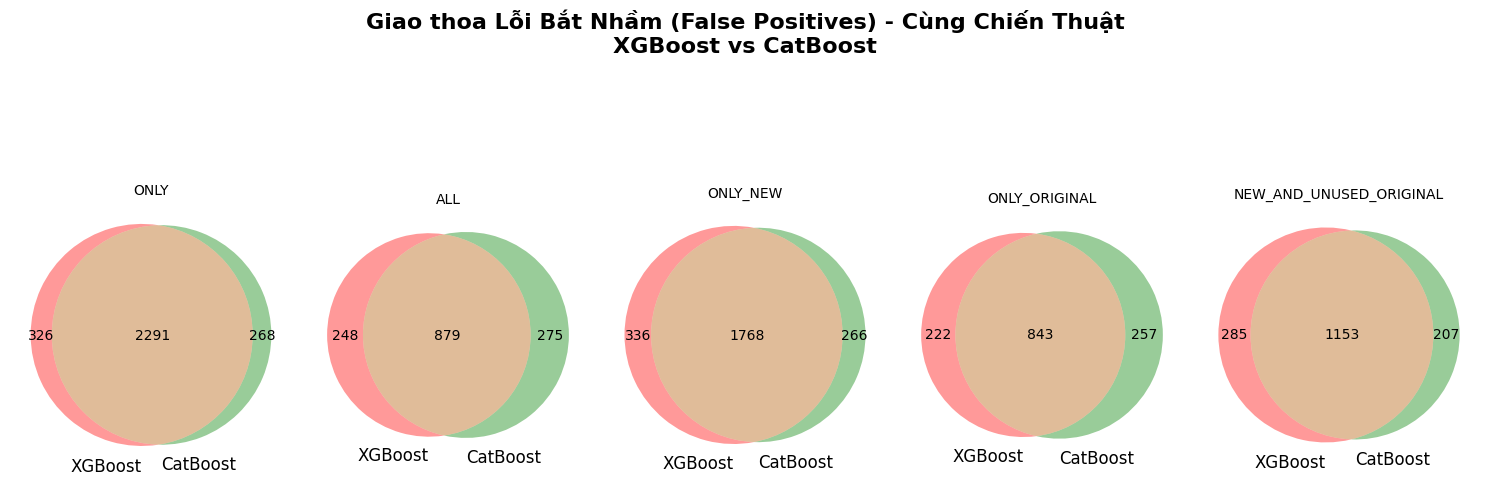

ValueError: subset_size="auto" cannot be used for a Series with non-unique groups.

<Figure size 1200x500 with 0 Axes>

In [11]:
# ---------------------------------------------------------
# 1. VẼ VENN DIAGRAM SO SÁNH XGBOOST VS CATBOOST (CÙNG CHIẾN THUẬT)
# ---------------------------------------------------------
strategies = list(hybrid_datasets.keys())
plt.figure(figsize=(15, 6))
plt.suptitle("Giao thoa Lỗi Bắt Nhầm (False Positives) - Cùng Chiến Thuật\nXGBoost vs CatBoost", fontweight='bold', fontsize=16)

for i, strategy in enumerate(strategies):
    plt.subplot(1, 5, i+1)
    k_xgb = f'XGB_{strategy}'
    k_cb  = f'CB_{strategy}'
    v = venn2([fp_sets[k_xgb], fp_sets[k_cb]], set_labels=('XGBoost', 'CatBoost'))
    plt.title(f"{strategy.replace('QUANTUM_', '')}", fontsize=10)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# ---------------------------------------------------------
# 2. UPSET PLOT: GIAO THOA LỖI CỦA 5 CHIẾN THUẬT XGBOOST
# ---------------------------------------------------------
def prepare_upset_data(model_keys, fp_list):
    all_fps = set()
    for fp in fp_list:
        all_fps.update(fp)
    
    data = []
    for item in all_fps:
        memberships = []
        for i, key in enumerate(model_keys):
            if item in fp_list[i]:
                memberships.append(key.replace('QUANTUM_', '').replace('XGB_', '').replace('CB_', ''))
        data.append(memberships)
    return from_memberships(data)

xgb_keys = [k for k in all_test_probs.keys() if k.startswith('XGB_')]
xgb_fp_list = [list(fp_sets[k]) for k in xgb_keys]
upset_data_xgb = prepare_upset_data(xgb_keys, xgb_fp_list)

fig = plt.figure(figsize=(12, 5))
upset_plot(upset_data_xgb, fig=fig, element_size=40, intersection_plot_elements=5)
plt.suptitle("UpSet Plot: Giao thoa lỗi giữa 5 chiến thuật XGBoost", fontweight='bold', fontsize=14)
plt.show()

# ---------------------------------------------------------
# 3. UPSET PLOT: GIAO THOA LỖI CỦA 5 CHIẾN THUẬT CATBOOST
# ---------------------------------------------------------
cb_keys = [k for k in all_test_probs.keys() if k.startswith('CB_')]
cb_fp_list = [list(fp_sets[k]) for k in cb_keys]
upset_data_cb = prepare_upset_data(cb_keys, cb_fp_list)

fig2 = plt.figure(figsize=(12, 5))
upset_plot(upset_data_cb, fig=fig2, element_size=40, intersection_plot_elements=5)
plt.suptitle("UpSet Plot: Giao thoa lỗi giữa 5 chiến thuật CatBoost", fontweight='bold', fontsize=14)
plt.show()
